<a href="https://colab.research.google.com/github/sweethusband73/llm-translation-evaluation-chart/blob/main/figure19_gemba_da_ref_landscap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

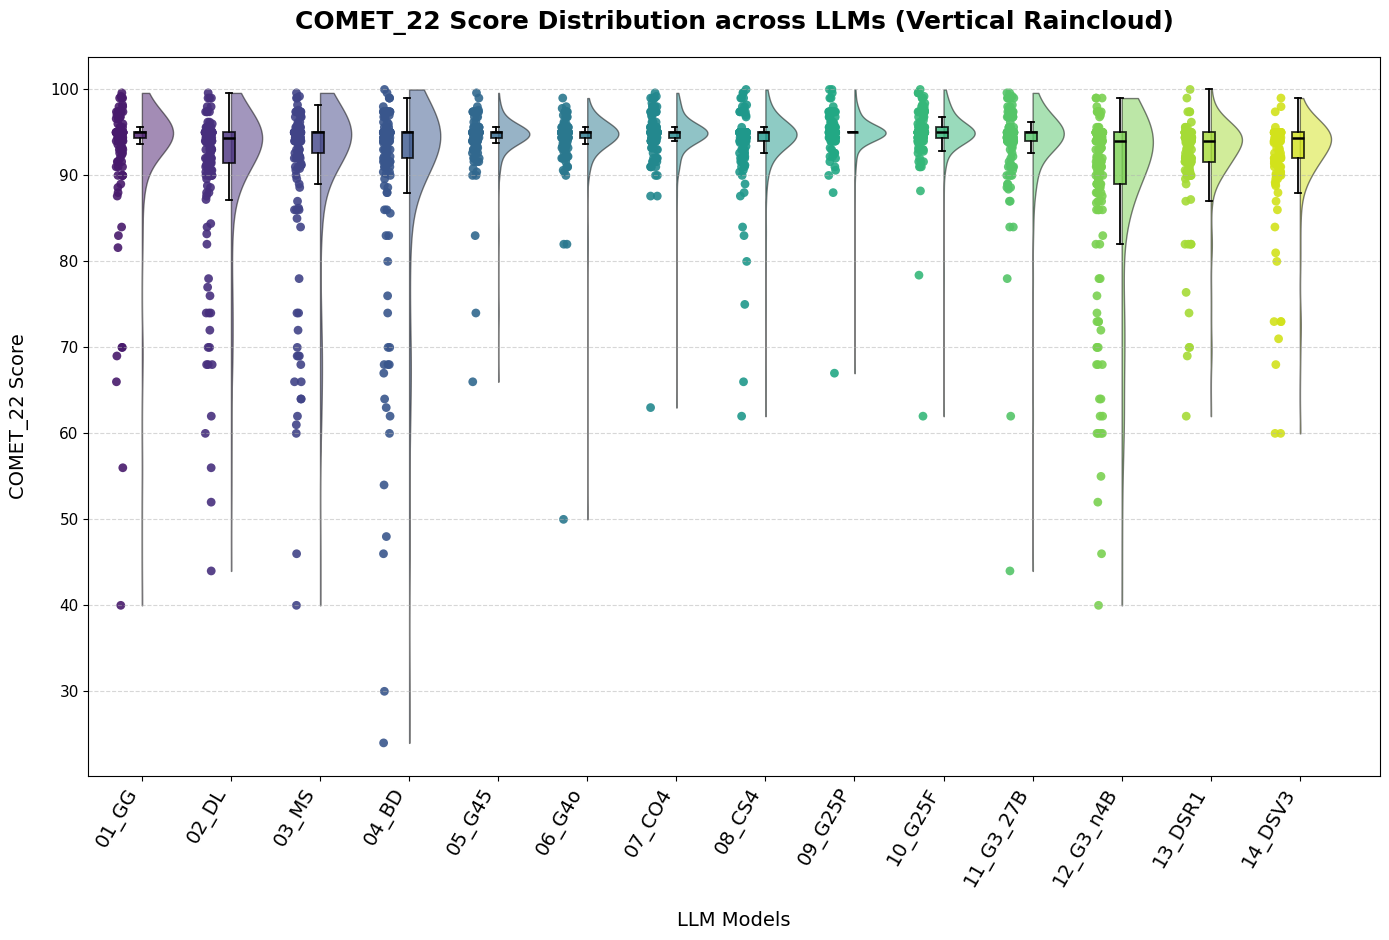

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. 讀取您的 CSV 檔案
df = pd.read_csv("4_Repeated_ANOVA_DAREF_0714_OK.csv")

# 2. 寬格式轉長格式
model_cols = df.columns[1:]
df_long = pd.melt(df, id_vars=['Sentence_ID'], value_vars=model_cols, var_name='LLM_Model', value_name='Score')

# 確保 'Score' 欄位是數值型態，並處理非數值資料 (保留您優良的清洗步驟)
df_long['Score'] = pd.to_numeric(df_long['Score'], errors='coerce')
df_long.dropna(subset=['Score'], inplace=True)

# 3. 設定畫布尺寸 (專為 A4 橫式優化：加高比例，減少橫向過扁的視覺感)
fig, ax = plt.subplots(figsize=(14, 9.5))
models = list(model_cols)
colors = sns.color_palette("viridis", len(models)) # 更改為 viridis 調色板，提供更鮮明的顏色

# 4. 【核心微調】手工精準定位與元件加寬
for i, model in enumerate(models):
    sub_data = df_long[df_long['LLM_Model'] == model]['Score'].values
    if len(sub_data) == 0:
        continue
    color = colors[i]

    # ─── 【右側】單邊雲朵 (調大寬度至 0.35，讓雲朵更飽滿好讀) ───
    kde = gaussian_kde(sub_data)
    y_vals = np.linspace(sub_data.min(), sub_data.max(), 250)
    x_vals = kde(y_vals)
    x_vals = (x_vals / x_vals.max()) * 0.35
    ax.fill_betweenx(y_vals, i, i + x_vals, color=color, alpha=0.5, edgecolor='black', linewidth=1.0)

    # ─── 【中間】細木箱 (核心修正：將位置微調至 i - 0.02，使其完美貼齊右側雲朵邊緣) ───
    ax.boxplot(sub_data, positions=[i - 0.02], widths=0.13, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, color='black', alpha=0.8, linewidth=1.3),
               medianprops=dict(color='black', linewidth=1.8),
               whiskerprops=dict(color='black', linewidth=1.3),
               capprops=dict(color='black', linewidth=1.3))

    # ─── 【左側】微型雨滴 (核心修正：配合箱子左移，散點也同步往左退到 i - 0.25) ───
    x_jitter = i - 0.25 + np.random.uniform(-0.04, 0.04, size=len(sub_data))
    ax.scatter(x_jitter, sub_data, color=color, alpha=0.9, s=40.0, edgecolor='none')

# 5. 調整標題、座標軸與字體 (放大字級，符合 A4 大圖閱讀)
ax.set_title("COMET_22 Score Distribution across LLMs (Vertical Raincloud)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("LLM Models", fontsize=14, labelpad=15)
ax.set_ylabel("COMET_22 Score", fontsize=14, labelpad=15)

# 固定 X 軸的標籤與位置
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=60, ha='right', fontsize=14)
ax.set_xlim(-0.6, len(models) - 0.1)
plt.yticks(fontsize=11)

# 加入淡灰色橫向虛線
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("LLM_Vertical_Raincloud_A4_Horizontal.png", dpi=300) # 輸出大圖
plt.show()